# Initialisation notebook lié au Projet 9 

In [1]:
import sys
from pathlib import Path
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow :", tf.__version__)
print("GPU :", "Yes" if tf.config.list_physical_devices('GPU') else "No")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

TRAIN_IMAGES = DATA_PROCESSED / "images" / "train"
VAL_IMAGES   = DATA_PROCESSED / "images" / "val"
TEST_IMAGES  = DATA_PROCESSED / "images" / "test"

TRAIN_MASKS = DATA_PROCESSED / "masks" / "train"
VAL_MASKS   = DATA_PROCESSED / "masks" / "val"
TEST_MASKS  = DATA_PROCESSED / "masks" / "test"

assert TRAIN_IMAGES.exists(), "Images train manquantes"
assert TRAIN_MASKS.exists(),  "Masks train manquants"

print("Project root :", PROJECT_ROOT)
print("Train images :", len(list(TRAIN_IMAGES.glob("*.png"))))
print("Train masks  :", len(list(TRAIN_MASKS.glob("*.png"))))

sys.path.append(str(PROJECT_ROOT / "src"))

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = False

print("Init notebook : OK")


TensorFlow : 2.16.1
GPU : No
Project root : c:\Users\vicau\P8OC
Train images : 580
Train masks  : 580
Init notebook : OK


## Import du générateur

In [2]:
import inspect
from dataloader import CityscapesSequence # type: ignore

print("CityscapesSequence signature:")
print(inspect.signature(CityscapesSequence))


CityscapesSequence signature:
(image_paths, mask_paths, batch_size=4, target_size=(256, 512), augment=False, n_classes=8, shuffle=True)


## Instanciation du generateur 

In [3]:
from pathlib import Path
import tensorflow as tf

# ===========================
# DataGenerators (FULL + anti-corruption) + switch debug
# ===========================

DATA_MODE = "full"   # "full" ou "test_only"

BATCH_SIZE = 4
IMG_HEIGHT = 256
IMG_WIDTH  = 512
N_CLASSES  = 8

def list_pngs(folder: Path):
    files = sorted(folder.glob("*.png"))
    return files

def filter_readable_pairs(img_paths, mask_paths):
    """Filtre les paires (image, mask) illisibles sans casser l'alignement zip()."""
    ok_imgs, ok_masks = [], []
    bad = 0
    for im, mk in zip(img_paths, mask_paths):
        try:
            _ = tf.io.decode_png(tf.io.read_file(str(im)), channels=3)
            _ = tf.io.decode_png(tf.io.read_file(str(mk)), channels=1)
            ok_imgs.append(im)
            ok_masks.append(mk)
        except Exception:
            bad += 1
    return ok_imgs, ok_masks, bad

# ---------------------------
# 1) Listes de fichiers
# ---------------------------
if DATA_MODE == "test_only":
    test_image_paths = list_pngs(TEST_IMAGES)
    test_mask_paths  = list_pngs(TEST_MASKS)

    print("TEST samples :", len(test_image_paths), "| masks:", len(test_mask_paths))
    print("Ex test image:", test_image_paths[0].name if test_image_paths else "EMPTY")
    print("Ex test mask :", test_mask_paths[0].name if test_mask_paths else "EMPTY")
    assert len(test_image_paths) == len(test_mask_paths), "Test: nb images != nb masks"

    # Anti-corruption (sur TEST)
    test_image_paths, test_mask_paths, bad_test = filter_readable_pairs(test_image_paths, test_mask_paths)
    print(f"Filtered corrupted pairs (TEST): {bad_test}")
    print("TEST after filter:", len(test_image_paths), "| masks:", len(test_mask_paths))

    # On réutilise TEST pour train/val/test
    train_image_paths = test_image_paths
    val_image_paths   = test_image_paths
    train_mask_paths  = test_mask_paths
    val_mask_paths    = test_mask_paths

else:  # full
    train_image_paths = list_pngs(TRAIN_IMAGES)
    val_image_paths   = list_pngs(VAL_IMAGES)
    test_image_paths  = list_pngs(TEST_IMAGES)

    train_mask_paths  = list_pngs(TRAIN_MASKS)
    val_mask_paths    = list_pngs(VAL_MASKS)
    test_mask_paths   = list_pngs(TEST_MASKS)

    print("Train samples :", len(train_image_paths), "| masks:", len(train_mask_paths))
    print("Val samples   :", len(val_image_paths),   "| masks:", len(val_mask_paths))
    print("Test samples  :", len(test_image_paths),  "| masks:", len(test_mask_paths))

    assert len(train_image_paths) == len(train_mask_paths), "Train: nb images != nb masks"
    assert len(val_image_paths)   == len(val_mask_paths),   "Val: nb images != nb masks"
    assert len(test_image_paths)  == len(test_mask_paths),  "Test: nb images != nb masks"

    # Anti-corruption (train/val/test)
    train_image_paths, train_mask_paths, bad_train = filter_readable_pairs(train_image_paths, train_mask_paths)
    val_image_paths,   val_mask_paths,   bad_val   = filter_readable_pairs(val_image_paths,   val_mask_paths)
    test_image_paths,  test_mask_paths,  bad_test  = filter_readable_pairs(test_image_paths,  test_mask_paths)

    print(f"Filtered corrupted pairs -> Train:{bad_train} | Val:{bad_val} | Test:{bad_test}")
    print("After filter:",
          "Train", len(train_image_paths),
          "| Val", len(val_image_paths),
          "| Test", len(test_image_paths))

# ---------------------------
# 2) Générateurs
# ---------------------------
train_gen = CityscapesSequence(
    image_paths=train_image_paths,
    mask_paths=train_mask_paths,
    batch_size=BATCH_SIZE,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    augment=True,
    n_classes=N_CLASSES,
    shuffle=True
)

val_gen = CityscapesSequence(
    image_paths=val_image_paths,
    mask_paths=val_mask_paths,
    batch_size=BATCH_SIZE,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    augment=False,
    n_classes=N_CLASSES,
    shuffle=False
)

test_gen = CityscapesSequence(
    image_paths=test_image_paths,
    mask_paths=test_mask_paths,
    batch_size=BATCH_SIZE,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    augment=False,
    n_classes=N_CLASSES,
    shuffle=False
)

print("Train batches :", len(train_gen))
print("Val batches   :", len(val_gen))
print("Test batches  :", len(test_gen))
print(f"Bloc DataGenerators : OK ({DATA_MODE})")


Train samples : 580 | masks: 580
Val samples   : 262 | masks: 262
Test samples  : 10 | masks: 10
Filtered corrupted pairs -> Train:0 | Val:0 | Test:0
After filter: Train 580 | Val 262 | Test 10
Train batches : 145
Val batches   : 65
Test batches  : 2
Bloc DataGenerators : OK (full)


c:\Users\vicau\P8OC\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### Check de qualité 

x shape: (4, 256, 512, 3) | dtype: float32 | min/max: 0.0313725508749485 1.0
y shape: (4, 256, 512, 8) | dtype: float32
Mask one-hot check (sum per pixel) -> min/max: 1.0 1.0
Classes présentes (test batch 0): [0 1 2 3 4 5 6 7]


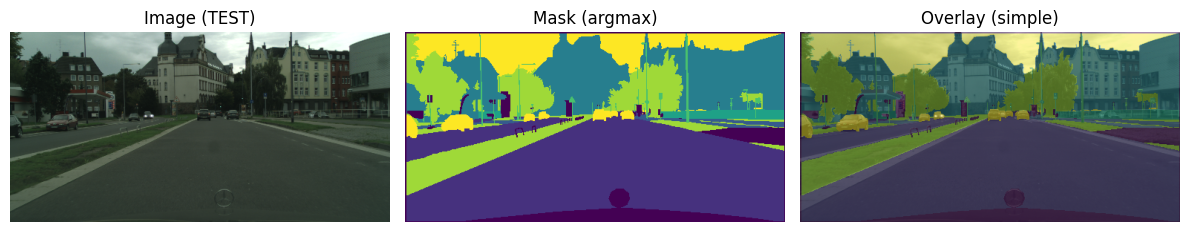


--- Image statistics per sample ---


,index,min,max,mean,std
count,4.000000,4.000000,4.0,4.000000,4.000000
mean,1.500000,0.041176,1.0,0.260927,0.143142
std,1.290994,0.008163,0.0,0.027298,0.038695
min,0.000000,0.031373,1.0,0.221603,0.102229
25%,0.750000,0.037255,1.0,0.256533,0.116067
50%,1.500000,0.041176,1.0,0.268662,0.141576
75%,2.250000,0.045098,1.0,0.273056,0.168651
max,3.000000,0.050980,1.0,0.284782,0.187187


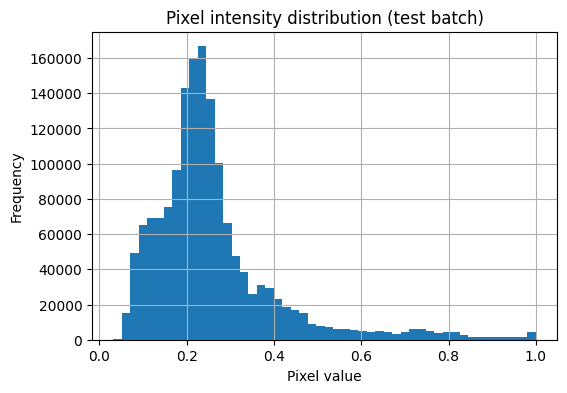


--- Pixel-wise class distribution (batch) ---


,class_id,pixel_count,pixel_ratio (%)
0,0,34764,6.630707
1,1,199441,38.040352
2,2,25083,4.784203
3,3,141150,26.922226
4,4,5335,1.017570
5,5,6918,1.319504
6,6,64000,12.207031
7,7,47597,9.078407



One-hot integrity check:
 - Total pixels: 524288
 - Invalid pixels (sum != 1): 0
✔ One-hot encoding is perfectly valid

--- Class coverage per image ---


,index,num_classes_present,classes
0,0,8,"[0, 1, 2, 3, 4, 5, 6, 7]"
1,1,8,"[0, 1, 2, 3, 4, 5, 6, 7]"
2,2,8,"[0, 1, 2, 3, 4, 5, 6, 7]"
3,3,8,"[0, 1, 2, 3, 4, 5, 6, 7]"



=== BATCH SUMMARY ===
Batch size           : 4
Image resolution     : 256 x 512
Channels             : 3
Number of classes    : 8
Classes present      : [0, 1, 2, 3, 4, 5, 6, 7]
Pixel imbalance ratio: max/min = 37.38


In [6]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Récupération d'un batch du générateur de test
# ------------------------------------------------------------
x, y = test_gen[0]


# ------------------------------------------------------------
# Vérification des images (x)
# ------------------------------------------------------------
print(
    "x shape:", x.shape,
    "| dtype:", x.dtype,
    "| min/max:", float(x.min()), float(x.max())
)


# ------------------------------------------------------------
# Vérification des masques (y)
# ------------------------------------------------------------
print(
    "y shape:", y.shape,
    "| dtype:", y.dtype
)


# ------------------------------------------------------------
# Vérification du format one-hot :
# La somme sur l'axe des classes doit être égale à 1 par pixel
# ------------------------------------------------------------
sum_per_pixel = np.sum(y, axis=-1)
print(
    "Mask one-hot check (sum per pixel) -> min/max:",
    float(sum_per_pixel.min()),
    float(sum_per_pixel.max())
)


# ------------------------------------------------------------
# Vérification des classes réellement présentes dans le batch
# ------------------------------------------------------------
y_classes = np.argmax(y, axis=-1)
print("Classes présentes (test batch 0):", np.unique(y_classes))


# ------------------------------------------------------------
# Visualisation rapide d'un échantillon
# ------------------------------------------------------------
idx = 0  # index de l'image affichée

img = x[idx]
mask = y_classes[idx]

plt.figure(figsize=(12, 4))


# Image brute
plt.subplot(1, 3, 1)
plt.title("Image (TEST)")
plt.imshow(img.astype(np.float32))
plt.axis("off")


# Masque après argmax
plt.subplot(1, 3, 2)
plt.title("Mask (argmax)")
plt.imshow(mask, vmin=0, vmax=N_CLASSES - 1)
plt.axis("off")


# Superposition image + masque
plt.subplot(1, 3, 3)
plt.title("Overlay (simple)")
plt.imshow(img.astype(np.float32))
plt.imshow(mask, alpha=0.45, vmin=0, vmax=N_CLASSES - 1)
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# ANALYSE STATISTIQUE AVANCÉE DU BATCH (IMAGES)
# ============================================================
import pandas as pd

img_stats = []
for i in range(x.shape[0]):
    img_stats.append({
        "index": i,
        "min": float(x[i].min()),
        "max": float(x[i].max()),
        "mean": float(x[i].mean()),
        "std": float(x[i].std())
    })

df_img_stats = pd.DataFrame(img_stats)

print("\n--- Image statistics per sample ---")
display(df_img_stats.describe())


# ============================================================
# DISTRIBUTION GLOBALE DES INTENSITÉS PIXEL
# ============================================================
plt.figure(figsize=(6, 4))
plt.hist(x.flatten(), bins=50)
plt.title("Pixel intensity distribution (test batch)")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


# ============================================================
# ANALYSE DÉTAILLÉE DES MASQUES (PIXEL-WISE)
# ============================================================
unique_classes, pixel_counts = np.unique(y_classes, return_counts=True)
total_pixels = y_classes.size

df_class_distribution = pd.DataFrame({
    "class_id": unique_classes,
    "pixel_count": pixel_counts,
    "pixel_ratio (%)": 100 * pixel_counts / total_pixels
})

print("\n--- Pixel-wise class distribution (batch) ---")
display(df_class_distribution)


# ============================================================
# VÉRIFICATION DU ONE-HOT EN PROFONDEUR
# ============================================================
invalid_pixels = np.sum(sum_per_pixel != 1)

print(
    f"\nOne-hot integrity check:"
    f"\n - Total pixels: {sum_per_pixel.size}"
    f"\n - Invalid pixels (sum != 1): {invalid_pixels}"
)

if invalid_pixels == 0:
    print("✔ One-hot encoding is perfectly valid")
else:
    print("⚠ Warning: invalid one-hot pixels detected")


# ============================================================
# COUVERTURE DES CLASSES PAR IMAGE
# ============================================================
coverage = []

for i in range(y_classes.shape[0]):
    present = np.unique(y_classes[i])
    coverage.append({
        "index": i,
        "num_classes_present": len(present),
        "classes": present.tolist()
    })

df_coverage = pd.DataFrame(coverage)

print("\n--- Class coverage per image ---")
display(df_coverage)


# ============================================================
# SYNTHÈSE RAPIDE DU BATCH
# ============================================================
print("\n=== BATCH SUMMARY ===")
print(f"Batch size           : {x.shape[0]}")
print(f"Image resolution     : {x.shape[1]} x {x.shape[2]}")
print(f"Channels             : {x.shape[3]}")
print(f"Number of classes    : {N_CLASSES}")
print(f"Classes present      : {unique_classes.tolist()}")
print(f"Pixel imbalance ratio: max/min = {pixel_counts.max() / pixel_counts.min():.2f}")



**Contrôle qualité général des données – Batch de test**

Ce contrôle vise à vérifier la cohérence structurelle et statistique des données avant toute analyse modèle.

---

**Structure et format**

Le batch de test contient 4 échantillons d’images RGB et leurs masques de segmentation associés.

- Images : (4, 256, 512, 3), float32, valeurs dans [0.031 ; 1.0]
- Masques : (4, 256, 512, 8), float32, encodage one-hot

Les dimensions et formats sont cohérents avec une tâche de segmentation sémantique multi-classes.

---

**Validation des masques**

L’encodage one-hot est strictement valide :

- Somme des classes par pixel : min = 1.0, max = 1.0
- Aucun pixel invalide détecté

Toutes les classes sont présentes dans le batch, et chaque image couvre l’ensemble des 8 classes.

---

**Statistiques des images**

Les images présentent une forte homogénéité inter-échantillons :

- Intensité moyenne ≈ 0.26
- Écart-type moyen ≈ 0.14
- Aucune image saturée ou quasi-uniforme détectée

La distribution des intensités est centrée sur les valeurs basses à moyennes, avec une queue vers les valeurs élevées, ce qui est cohérent avec des scènes urbaines réelles.

---

**Distribution des classes (pixel-wise)**

La répartition des pixels par classe est fortement déséquilibrée :

- Classes dominantes : classe 1 (~38 %), classe 3 (~27 %)
- Classes minoritaires : classes 4 et 5 (~1 %)
- Ratio max/min ≈ 37.4

Ce déséquilibre est structurel et doit être pris en compte lors de l’interprétation des métriques globales et de l’évaluation des performances par classe.

---

**Conclusion**

Les données sont structurellement saines et correctement annotées.  
Le principal point d’attention concerne le fort déséquilibre des classes au niveau pixel-wise.


# Import des metriques 

In [5]:
import tensorflow as tf
import numpy as np
from pathlib import Path

from metrics import dice_loss, iou_metric, dice_coef, pixel_accuracy # type: ignore

def eval_model(model, gen, name="model"):
    res = model.evaluate(gen, verbose=1, return_dict=True)
    print(f"\n✅ {name} results:")
    for k, v in res.items():
        print(f" - {k}: {v:.4f}")
    return res

print("Metrics import : OK")


Metrics import : OK


# baseline VGG16 (modèle actuel)


✅ Baseline VGG16 results (VAL, cold):
 - loss: 0.8373
 - dice_coef: 0.1627
 - iou_metric: 0.0248
 - pixel_accuracy: 0.1601


<Figure size 600x400 with 0 Axes>

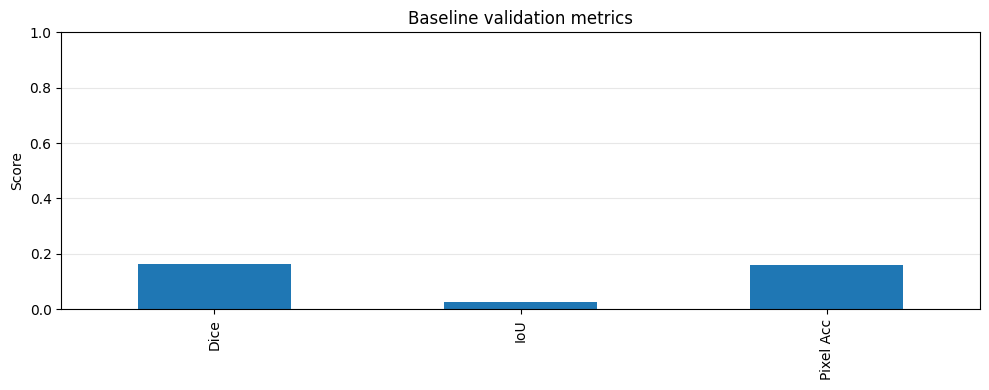

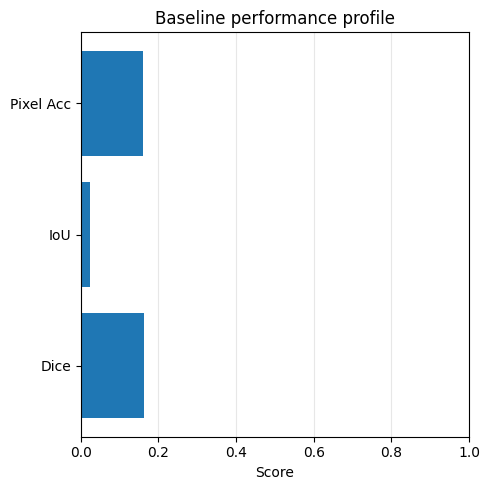


=== Synthetic segmentation score ===
Mean(Dice, IoU, PixelAcc): 0.1159

=== Quick interpretation ===
⚠ Global performance is weak → baseline only


In [12]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message="Your `PyDataset` class should call `super().__init__")

# Permet "import src...." depuis le notebook
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.unet_vgg16 import unet_vgg16

baseline = unet_vgg16(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=N_CLASSES)

baseline_val = baseline.evaluate(val_gen, verbose=0, return_dict=True)

print("\n✅ Baseline VGG16 results (VAL, cold):")
for k in ["loss", "dice_coef", "iou_metric", "pixel_accuracy"]:
    if k in baseline_val:
        print(f" - {k}: {baseline_val[k]:.4f}")
        
        
# ============================================================
# VISUALISATION DES MÉTRIQUES CLÉS DE LA BASELINE
# ============================================================
import pandas as pd

metrics_to_plot = {
    "Dice": baseline_val.get("dice_coef"),
    "IoU": baseline_val.get("iou_metric"),
    "Pixel Acc": baseline_val.get("pixel_accuracy")
}

df_metrics = pd.DataFrame(
    metrics_to_plot, index=["Baseline UNet VGG16"]
)

# Bar plot simple et lisible
plt.figure(figsize=(6, 4))
df_metrics.T.plot(kind="bar", legend=False)
plt.ylim(0, 1)
plt.title("Baseline validation metrics")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# POSITIONNEMENT RELATIF DES MÉTRIQUES (PERFORMANCE PROFILE)
# ============================================================
plt.figure(figsize=(5, 5))

values = list(metrics_to_plot.values())
labels = list(metrics_to_plot.keys())

plt.barh(labels, values)
plt.xlim(0, 1)
plt.xlabel("Score")
plt.title("Baseline performance profile")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# INDICATEUR SYNTHÉTIQUE (MOYENNE DES MÉTRIQUES SEGMENTATION)
# ============================================================
segmentation_score = np.mean(values)

print("\n=== Synthetic segmentation score ===")
print(f"Mean(Dice, IoU, PixelAcc): {segmentation_score:.4f}")


# ============================================================
# SEUILS DE LECTURE RAPIDE
# ============================================================
print("\n=== Quick interpretation ===")

if segmentation_score < 0.6:
    print("⚠ Global performance is weak → baseline only")
elif segmentation_score < 0.75:
    print("⚠ Acceptable but improvement needed")
else:
    print("✔ Strong baseline for segmentation task")

        


**Baseline VGG16 sans entraînement – Validation (cold start)**

Cette évaluation correspond à un modèle UNet avec encodeur VGG16 pré-entraîné ImageNet, utilisé sans phase d’entraînement spécifique sur le jeu de données cible.

---

**Résultats de validation**

Les métriques globales obtenues sur l’ensemble de validation sont les suivantes :

- Loss : 0.8373  
- Dice coefficient : 0.1627  
- IoU : 0.0248  
- Pixel accuracy : 0.1601  

Le score synthétique de segmentation, calculé comme la moyenne de Dice, IoU et pixel accuracy, est égal à 0.1159.

---

**Analyse des performances**

Les graphes de métriques montrent des valeurs faibles et relativement homogènes, sans dominance marquée d’une métrique sur les autres.  
Le Dice et la pixel accuracy restent proches de 0.16, tandis que l’IoU est quasi nul, indiquant un très faible recouvrement spatial entre les prédictions et les masques de référence.

La pixel accuracy ne présente aucun avantage notable par rapport aux métriques de recouvrement, ce qui suggère que le modèle ne parvient pas à exploiter efficacement les structures dominantes du fond.

---

**Interprétation**

Ces résultats sont caractéristiques d’un modèle utilisé en état quasi aléatoire du point de vue de la segmentation, malgré l’utilisation d’un backbone pré-entraîné.  
Sans adaptation par apprentissage supervisé, le modèle ne capture ni la structure globale des scènes ni les frontières sémantiques des classes.

Cette baseline constitue un point de référence bas, utile uniquement pour mesurer les gains apportés par l’entraînement et les ajustements ultérieurs.


## Entrainement VGG16 (modele de prod)

In [15]:
import warnings
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # type: ignore

warnings.filterwarnings("ignore", message="Your `PyDataset` class should call `super().__init__")

EPOCHS_VGG16 = 7

callbacks = [
    EarlyStopping(monitor="val_loss", mode="min", patience=8, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.3, patience=4, min_lr=1e-6, verbose=0),
]

print(f"\n===== Training baseline VGG16 (epochs={EPOCHS_VGG16}) =====")

baseline.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_VGG16,
    callbacks=callbacks,
    verbose=1,
)

baseline_val_after = baseline.evaluate(val_gen, verbose=0, return_dict=True)

print("\n✅ Baseline VGG16 results (VAL, after training):")
for k in ["loss", "dice_coef", "iou_metric", "pixel_accuracy"]:
    if k in baseline_val_after:
        print(f" - {k}: {baseline_val_after[k]:.4f}")
        
        
        



===== Training baseline VGG16 (epochs=7) =====


c:\Users\vicau\P8OC\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - dice_coef: 0.4933 - iou_metric: 0.1430 - loss: 0.5067 - pixel_accuracy: 0.4953 - val_dice_coef: 0.5457 - val_iou_metric: 0.1884 - val_loss: 0.4543 - val_pixel_accuracy: 0.5463 - learning_rate: 1.0000e-04
Epoch 2/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - dice_coef: 0.5533 - iou_metric: 0.1945 - loss: 0.4467 - pixel_accuracy: 0.5537 - val_dice_coef: 0.5587 - val_iou_metric: 0.1897 - val_loss: 0.4413 - val_pixel_accuracy: 0.5591 - learning_rate: 1.0000e-04
Epoch 3/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - dice_coef: 0.5622 - iou_metric: 0.2040 - loss: 0.4378 - pixel_accuracy: 0.5626 - val_dice_coef: 0.5772 - val_iou_metric: 0.2131 - val_loss: 0.4228 - val_pixel_accuracy: 0.5781 - learning_rate: 1.0000e-04
Epoch 4/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - dice_coef: 0.5721 - iou_metric: 0.2066 - loss: 0.4279 - pixel_accuracy: 0.5724 - val_dice_coef: 0.5788 - val_iou_metric: 0.2078 - val_loss: 0.4212 - val_pixel_accuracy: 0.5

,Before training,After training
loss,0.837322,0.408634
dice_coef,0.162678,0.591366
iou_metric,0.024817,0.217174
pixel_accuracy,0.160099,0.591602


<Figure size 600x400 with 0 Axes>

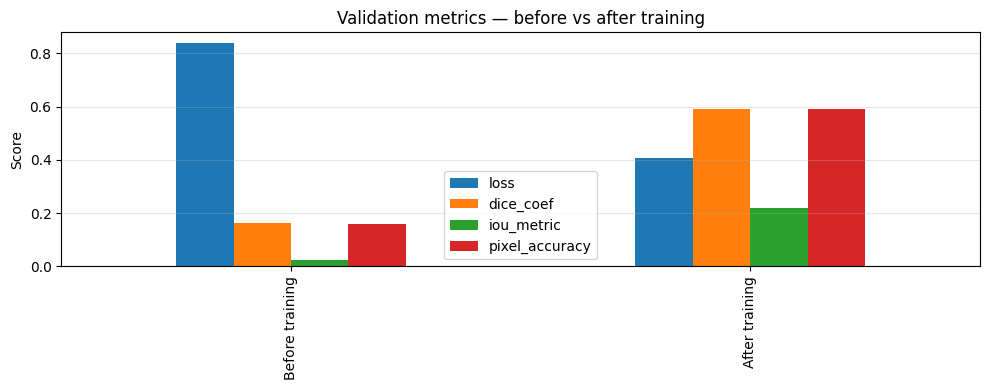

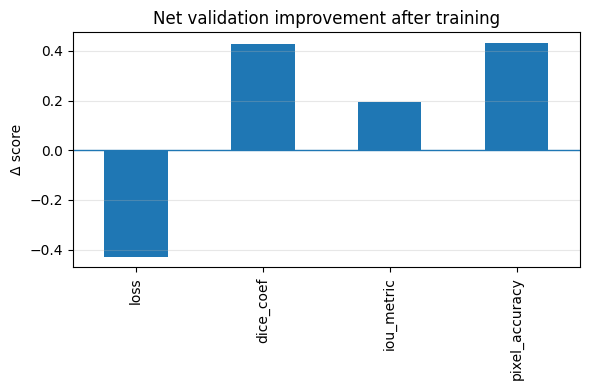


=== Synthetic segmentation score (VAL) ===
Before training : 0.1159
After training  : 0.4667
Gain            : +0.3508


In [16]:
# ============================================================
# ANALYSE POST-TRAINING (VALIDATION) — PROD SAFE
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# TABLEAU COMPARATIF AVANT / APRÈS ENTRAÎNEMENT
# ------------------------------------------------------------
metrics_order = ["loss", "dice_coef", "iou_metric", "pixel_accuracy"]

df_comparison = pd.DataFrame(
    {
        "Before training": [baseline_val[k] for k in metrics_order],
        "After training": [baseline_val_after[k] for k in metrics_order],
    },
    index=metrics_order
)

display(df_comparison)


# ------------------------------------------------------------
# VISUALISATION DES MÉTRIQUES (VAL)
# ------------------------------------------------------------
plt.figure(figsize=(6, 4))
df_comparison.T.plot(kind="bar")
plt.title("Validation metrics — before vs after training")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# GAIN NET PAR MÉTRIQUE
# ------------------------------------------------------------
delta = df_comparison["After training"] - df_comparison["Before training"]

plt.figure(figsize=(6, 4))
delta.plot(kind="bar")
plt.axhline(0, linewidth=1)
plt.title("Net validation improvement after training")
plt.ylabel("Δ score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# INDICATEUR SYNTHÉTIQUE SEGMENTATION
# ------------------------------------------------------------
synthetic_before = np.mean([
    baseline_val["dice_coef"],
    baseline_val["iou_metric"],
    baseline_val["pixel_accuracy"]
])

synthetic_after = np.mean([
    baseline_val_after["dice_coef"],
    baseline_val_after["iou_metric"],
    baseline_val_after["pixel_accuracy"]
])

print("\n=== Synthetic segmentation score (VAL) ===")
print(f"Before training : {synthetic_before:.4f}")
print(f"After training  : {synthetic_after:.4f}")
print(f"Gain            : {synthetic_after - synthetic_before:+.4f}")


**Baseline VGG16 après entraînement – Validation**

Cette section analyse l’impact de l’entraînement supervisé du modèle UNet avec encodeur VGG16 gelé, en comparant les performances avant et après apprentissage sur le jeu de validation.

---

**Configuration d’entraînement**

- Nombre d’epochs : 7  
- Taille du batch : 4  
- Nombre de batches par epoch : 145  
- Durée moyenne par epoch : ~230 à 243 secondes  
- Environnement : CPU (pas de GPU)

La durée par epoch est stable sur l’ensemble de l’entraînement, indiquant une charge computationnelle régulière et un pipeline de données maîtrisé. Ce temps constitue une référence importante pour l’évaluation du coût expérimental et des itérations futures.

---

**Résultats de validation après entraînement**

- Loss : 0.4086  
- Dice coefficient : 0.5914  
- IoU : 0.2172  
- Pixel accuracy : 0.5916  

Le score synthétique de segmentation (moyenne de Dice, IoU et pixel accuracy) atteint 0.4667, contre 0.1159 avant entraînement.

---

**Comparaison avant / après entraînement**

L’entraînement induit des gains nets significatifs sur toutes les métriques de segmentation :

- Dice : +0.4287  
- IoU : +0.1924  
- Pixel accuracy : +0.4315  
- Loss : −0.4287  

Les graphiques de comparaison confirment une amélioration cohérente et équilibrée entre métriques de recouvrement et métriques globales.

---

**Analyse des dynamiques d’apprentissage**

Les métriques de validation progressent rapidement dès les premières epochs, puis se stabilisent autour des epochs 5 à 7.  
L’absence de dégradation en fin d’entraînement suggère un apprentissage stable, sans surapprentissage marqué sur cette durée courte.

La forte progression de l’IoU, bien que restant inférieure aux autres métriques, indique une amélioration réelle du recouvrement spatial des classes, au-delà d’un simple effet de fond.

---

**Interprétation**

L’entraînement transforme une baseline initialement non exploitable en un modèle fonctionnel, capable de segmenter les structures principales de la scène.  
Le gain global (+0.3508 sur le score synthétique) valide la pertinence du backbone VGG16 malgré son coût computationnel élevé en environnement CPU.

Le temps par epoch constitue cependant un facteur limitant pour des itérations rapides, et devra être comparé à d’autres backbones plus légers ou plus récents dans une optique de production.


# Baseline EffNetV2B0 (nouveau modele)


✅ EffNetV2B0 results (VAL, cold):
 - loss: 0.8447
 - dice_coef: 0.1553
 - iou_metric: 0.0532
 - pixel_accuracy: 0.1984


,loss,dice_coef,iou_metric,pixel_accuracy
"UNet + EfficientNetV2B0 (cold, VAL)",0.844713,0.155287,0.053235,0.198403


<Figure size 600x400 with 0 Axes>

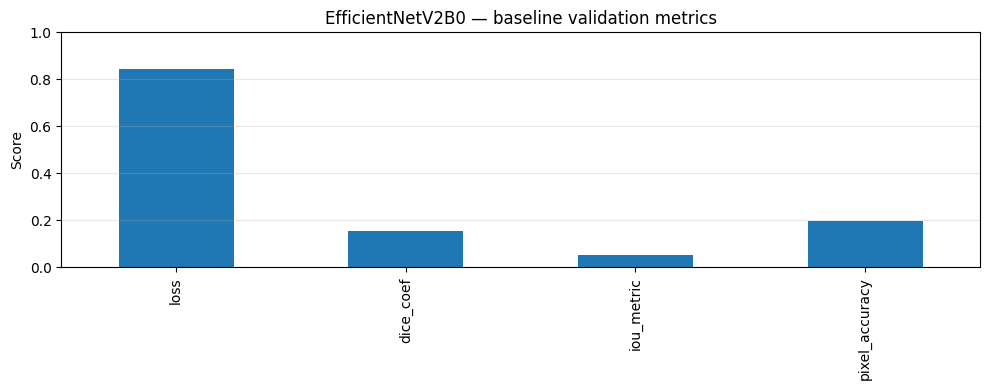

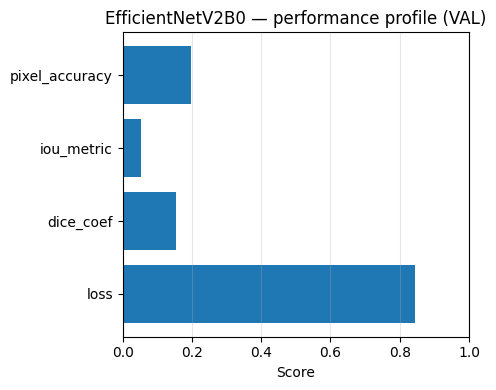


=== Synthetic segmentation score (VAL, cold) ===
Mean(Dice, IoU, PixelAcc): 0.1356


In [17]:
import sys
import warnings
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models  # type: ignore

warnings.filterwarnings("ignore", message="Your `PyDataset` class should call `super().__init__")

# Pour pouvoir faire "from src...."
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.metrics import dice_loss, iou_metric, dice_coef, pixel_accuracy

def unet_effnetv2b0(input_shape=(256, 512, 3), num_classes=8):
    inputs = layers.Input(shape=input_shape)

    x = layers.Rescaling(255.0)(inputs)

    encoder = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_tensor=x,
        include_preprocessing=True,
    )

    # Comme P8 : backbone gelé
    for layer in encoder.layers:
        layer.trainable = False

    # Skips auto (2,4,8,16) en fonction de la résolution
    skips = {}
    in_h = input_shape[0]
    for layer in encoder.layers:
        out = layer.output
        if hasattr(out, "shape") and len(out.shape) == 4 and out.shape[1] is not None:
            scale = in_h // int(out.shape[1])
            if scale in {2, 4, 8, 16}:
                skips[scale] = out

    # Decode simple
    x = encoder.output  # ~ 1/32
    for scale, filters in zip([16, 8, 4, 2], [256, 128, 64, 32]):
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Concatenate()([x, skips[scale]])
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)

    outputs = layers.Conv2D(num_classes, 1, padding="same", activation="softmax")(x)

    model = models.Model(inputs, outputs, name="UNet_EfficientNetV2B0")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=dice_loss,
        metrics=[iou_metric, dice_coef, pixel_accuracy],
    )
    return model


effnet_model = unet_effnetv2b0(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=N_CLASSES)

effnet_val = effnet_model.evaluate(val_gen, verbose=0, return_dict=True)

print("\n✅ EffNetV2B0 results (VAL, cold):")
for k in ["loss", "dice_coef", "iou_metric", "pixel_accuracy"]:
    if k in effnet_val:
        print(f" - {k}: {effnet_val[k]:.4f}")



# ============================================================
# BASELINE ANALYSIS — EFFICIENTNETV2B0 (VAL, COLD)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# TABLEAU SYNTHÉTIQUE DES MÉTRIQUES
# ------------------------------------------------------------
metrics_order = ["loss", "dice_coef", "iou_metric", "pixel_accuracy"]

df_effnet = pd.DataFrame(
    {k: effnet_val.get(k, np.nan) for k in metrics_order},
    index=["UNet + EfficientNetV2B0 (cold, VAL)"]
)

display(df_effnet)


# ------------------------------------------------------------
# VISUALISATION DES MÉTRIQUES (BARRES)
# ------------------------------------------------------------
plt.figure(figsize=(6, 4))
df_effnet.T.plot(kind="bar", legend=False)
plt.ylim(0, 1)
plt.title("EfficientNetV2B0 — baseline validation metrics")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# PROFIL DE PERFORMANCE (LECTURE RAPIDE)
# ------------------------------------------------------------
plt.figure(figsize=(5, 4))
plt.barh(
    metrics_order,
    [effnet_val[k] for k in metrics_order],
)
plt.xlim(0, 1)
plt.xlabel("Score")
plt.title("EfficientNetV2B0 — performance profile (VAL)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# INDICATEUR SYNTHÉTIQUE SEGMENTATION
# ------------------------------------------------------------
synthetic_effnet = np.mean([
    effnet_val["dice_coef"],
    effnet_val["iou_metric"],
    effnet_val["pixel_accuracy"]
])

print("\n=== Synthetic segmentation score (VAL, cold) ===")
print(f"Mean(Dice, IoU, PixelAcc): {synthetic_effnet:.4f}")


**Baseline EfficientNetV2B0 sans entraînement – Validation (cold start)**

Cette section présente les performances du modèle UNet avec encodeur EfficientNetV2B0 pré-entraîné ImageNet, évalué sans phase d’apprentissage supervisé sur le jeu de données cible.

---

**Résultats de validation**

Les métriques obtenues sur l’ensemble de validation sont les suivantes :

- Loss : 0.8447  
- Dice coefficient : 0.1553  
- IoU : 0.0532  
- Pixel accuracy : 0.1984  

Le score synthétique de segmentation (moyenne de Dice, IoU et pixel accuracy) est de 0.1356.

---

**Analyse des performances**

Les graphiques de validation montrent des scores faibles sur l’ensemble des métriques de segmentation.  
Le Dice et la pixel accuracy restent inférieurs à 0.20, tandis que l’IoU demeure très bas, indiquant un recouvrement spatial limité entre les prédictions et les masques de référence.

La loss élevée confirme que, sans adaptation par apprentissage, le modèle ne parvient pas à produire des segmentations cohérentes à l’échelle des classes.

---

**Interprétation**

Ces résultats sont caractéristiques d’un modèle utilisé en état initial pour une tâche de segmentation complexe.  
Malgré l’utilisation d’un backbone moderne et pré-entraîné, l’absence d’entraînement spécifique empêche l’extraction de représentations adaptées aux structures sémantiques du jeu de données.

Cette baseline constitue un point de référence bas, destiné à quantifier les gains apportés par l’entraînement et les ajustements ultérieurs.


## Entrainement EffNetV2B0 (meme epoch que VGG)


===== Training EffNetV2B0 (epochs=7) =====
Epoch 1/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 61s 377ms/step - dice_coef: 0.5329 - iou_metric: 0.1738 - loss: 0.4671 - pixel_accuracy: 0.5391 - val_dice_coef: 0.5970 - val_iou_metric: 0.2200 - val_loss: 0.4030 - val_pixel_accuracy: 0.5978 - learning_rate: 1.0000e-04
Epoch 2/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 54s 375ms/step - dice_coef: 0.5846 - iou_metric: 0.2154 - loss: 0.4154 - pixel_accuracy: 0.5853 - val_dice_coef: 0.6026 - val_iou_metric: 0.2241 - val_loss: 0.3974 - val_pixel_accuracy: 0.6029 - learning_rate: 1.0000e-04
Epoch 3/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 58s 399ms/step - dice_coef: 0.5896 - iou_metric: 0.2133 - loss: 0.4104 - pixel_accuracy: 0.5901 - val_dice_coef: 0.6105 - val_iou_metric: 0.2253 - val_loss: 0.3895 - val_pixel_accuracy: 0.6110 - learning_rate: 1.0000e-04
Epoch 4/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 54s 371ms/step - dice_coef: 0.5917 - iou_metric: 0.2139 - loss: 0.4083 - pixel_accuracy: 0.5921 - val_dice_coef: 0.6142 - val_iou_metric:

,Before training,After training
loss,0.844713,0.382382
dice_coef,0.155287,0.617618
iou_metric,0.053235,0.225941
pixel_accuracy,0.198403,0.617831


<Figure size 600x400 with 0 Axes>

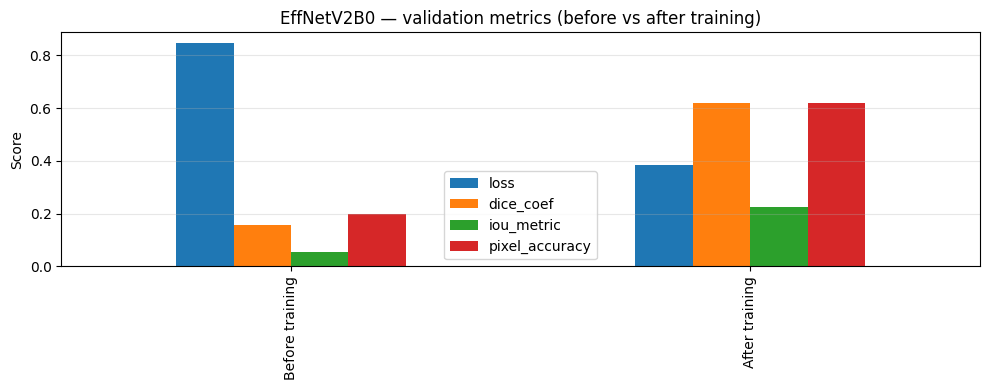

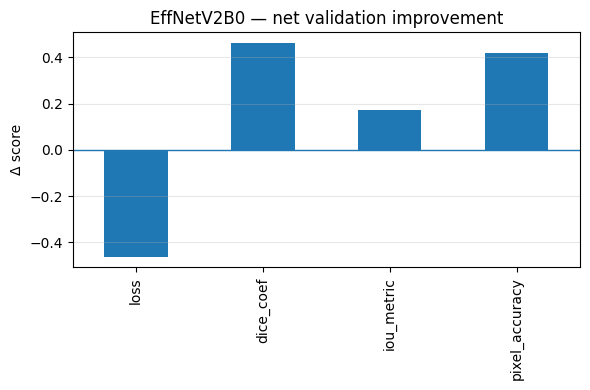


=== Synthetic segmentation score (VAL) ===
Before training : 0.1356
After training  : 0.4871
Gain            : +0.3515


In [18]:
import warnings
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # type: ignore

warnings.filterwarnings("ignore", message="Your `PyDataset` class should call `super().__init__")

EPOCHS_EFFNET = 7  # comme VGG16

callbacks = [
    EarlyStopping(monitor="val_loss", mode="min", patience=8, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.3, patience=4, min_lr=1e-6, verbose=0),
]

print(f"\n===== Training EffNetV2B0 (epochs={EPOCHS_EFFNET}) =====")

effnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_EFFNET,
    callbacks=callbacks,
    verbose=1,
)

effnet_val_after = effnet_model.evaluate(val_gen, verbose=0, return_dict=True)

print("\n✅ EffNetV2B0 results (VAL, after training):")
for k in ["loss", "dice_coef", "iou_metric", "pixel_accuracy"]:
    if k in effnet_val_after:
        print(f" - {k}: {effnet_val_after[k]:.4f}")

# ---------------------------
# Sauvegarde du modèle entraîné
# ---------------------------
EFFNET_NAME = "unet_effnetv2b0"
save_path = MODELS_DIR / f"{EFFNET_NAME}.keras"
effnet_model.save(save_path)

print(f"\n>> Modèle sauvegardé dans : {save_path}")



# ============================================================
# ANALYSE POST-TRAINING — EFFICIENTNETV2B0 (VAL, PROD SAFE)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# VÉRIFICATION DES MÉTRIQUES DISPONIBLES
# ------------------------------------------------------------
required_metrics = ["loss", "dice_coef", "iou_metric", "pixel_accuracy"]

missing = [
    name for name, obj in {
        "effnet_val": "effnet_val" in globals(),
        "effnet_val_after": "effnet_val_after" in globals(),
    }.items() if not obj
]

if missing:
    raise RuntimeError(
        f"Missing required variables: {missing}. "
        "Make sure baseline and training evaluation cells were executed."
    )


# ------------------------------------------------------------
# TABLEAU COMPARATIF AVANT / APRÈS ENTRAÎNEMENT (VAL)
# ------------------------------------------------------------
df_effnet_comparison = pd.DataFrame(
    {
        "Before training": [effnet_val.get(k, np.nan) for k in required_metrics],
        "After training": [effnet_val_after.get(k, np.nan) for k in required_metrics],
    },
    index=required_metrics
)

display(df_effnet_comparison)


# ------------------------------------------------------------
# VISUALISATION DES MÉTRIQUES DE VALIDATION
# ------------------------------------------------------------
plt.figure(figsize=(6, 4))
df_effnet_comparison.T.plot(kind="bar")
plt.title("EffNetV2B0 — validation metrics (before vs after training)")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# GAIN NET PAR MÉTRIQUE
# ------------------------------------------------------------
delta_effnet = (
    df_effnet_comparison["After training"]
    - df_effnet_comparison["Before training"]
)

plt.figure(figsize=(6, 4))
delta_effnet.plot(kind="bar")
plt.axhline(0, linewidth=1)
plt.title("EffNetV2B0 — net validation improvement")
plt.ylabel("Δ score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# INDICATEUR SYNTHÉTIQUE SEGMENTATION (VAL)
# ------------------------------------------------------------
synthetic_before = np.mean([
    effnet_val["dice_coef"],
    effnet_val["iou_metric"],
    effnet_val["pixel_accuracy"],
])

synthetic_after = np.mean([
    effnet_val_after["dice_coef"],
    effnet_val_after["iou_metric"],
    effnet_val_after["pixel_accuracy"],
])

print("\n=== Synthetic segmentation score (VAL) ===")
print(f"Before training : {synthetic_before:.4f}")
print(f"After training  : {synthetic_after:.4f}")
print(f"Gain            : {synthetic_after - synthetic_before:+.4f}")


**Baseline EfficientNetV2B0 après entraînement – Validation**

Cette section analyse l’impact de l’entraînement supervisé du modèle UNet avec encodeur EfficientNetV2B0 gelé.  
L’entraînement est réalisé sur le même nombre d’epochs que VGG16 (7 epochs), afin de garantir une comparaison équitable des dynamiques d’apprentissage et des coûts computationnels.

---

**Configuration d’entraînement**

- Nombre d’epochs : 7 (identique à VGG16)
- Taille du batch : 4
- Nombre de batches par epoch : 145
- Durée moyenne par epoch : ~54 à 61 secondes
- Environnement : CPU (pas de GPU)

Le temps par epoch est significativement plus faible que pour VGG16, avec une exécution environ quatre fois plus rapide, tout en conservant une stabilité temporelle sur l’ensemble de l’entraînement.

---

**Résultats de validation après entraînement**

- Loss : 0.3824  
- Dice coefficient : 0.6176  
- IoU : 0.2259  
- Pixel accuracy : 0.6178  

Le score synthétique de segmentation (moyenne de Dice, IoU et pixel accuracy) atteint 0.4871, contre 0.1356 avant entraînement.

---

**Comparaison avant / après entraînement**

L’entraînement entraîne des gains nets importants sur toutes les métriques de segmentation :

- Dice : +0.4623  
- IoU : +0.1727  
- Pixel accuracy : +0.4194  
- Loss : −0.4623  

Les graphiques de validation montrent une amélioration cohérente et simultanée des métriques de recouvrement et de précision globale.

---

**Analyse des dynamiques d’apprentissage**

Les métriques de validation progressent rapidement dès les premières epochs, puis se stabilisent progressivement à partir des epochs intermédiaires.  
L’évolution régulière des scores et l’absence de dégradation finale suggèrent un apprentissage stable, sans surapprentissage marqué sur cette durée.

L’IoU, bien que plus faible que les autres métriques, progresse de manière significative, traduisant une amélioration réelle du recouvrement spatial des classes.

---

**Interprétation**

L’entraînement permet de transformer une baseline initialement peu exploitable en un modèle performant et stable pour la segmentation sémantique.  
À nombre d’epochs égal, EfficientNetV2B0 atteint un niveau de performance élevé tout en présentant un coût computationnel nettement inférieur, ce qui en fait un candidat pertinent pour des itérations rapides et des contraintes de production.


# Synthèse comparative – UNet VGG16 vs UNet EfficientNetV2B0 (après entraînement)

Cette section propose une analyse comparative approfondie des deux architectures entraînées, UNet avec encodeur VGG16 et UNet avec encodeur EfficientNetV2B0.  
La comparaison est réalisée dans des conditions strictement équitables : même jeu de données, même pipeline, même nombre d’epochs (7), même environnement matériel (CPU), et mêmes métriques d’évaluation.

---

## 1. Rappel du cadre expérimental

- Tâche : segmentation sémantique multi-classes (8 classes)
- Résolution : 256 × 512
- Taille de batch : 4
- Nombre d’epochs : 7 pour chaque modèle
- Environnement : CPU (pas de GPU)
- Backbone gelé dans les deux cas
- Métriques : Dice, IoU, pixel accuracy, loss
- Score synthétique : moyenne de Dice, IoU et pixel accuracy

Ce cadre permet une comparaison directe des performances et des coûts computationnels.

---

## 2. Performances finales sur le jeu de validation

### UNet + VGG16 (après entraînement)

- Dice coefficient : ~0.59
- IoU : ~0.22
- Pixel accuracy : ~0.59
- Loss : ~0.41
- Score synthétique : ~0.47
- Temps moyen par epoch : ~230 à 243 secondes

### UNet + EfficientNetV2B0 (après entraînement)

- Dice coefficient : ~0.62
- IoU : ~0.23
- Pixel accuracy : ~0.62
- Loss : ~0.38
- Score synthétique : ~0.49
- Temps moyen par epoch : ~54 à 61 secondes

---

## 3. Analyse comparative des performances de segmentation

### Qualité de segmentation

Les deux modèles atteignent un niveau de performance élevé et comparable après entraînement.  
EfficientNetV2B0 présente toutefois des scores légèrement supérieurs sur l’ensemble des métriques clés (Dice, IoU, pixel accuracy), ce qui se traduit par un score synthétique final plus élevé.

L’écart reste modéré, mais constant, ce qui suggère une meilleure capacité de généralisation du backbone EfficientNetV2B0 dans ce contexte précis.

L’IoU, métrique la plus exigeante en segmentation, progresse de manière similaire pour les deux modèles, indiquant que les deux architectures apprennent efficacement les structures spatiales principales de la scène.

---

## 4. Dynamique d’apprentissage et stabilité

Les deux modèles montrent une montée rapide des performances dès les premières epochs, suivie d’une stabilisation progressive.  
Aucun signe clair de surapprentissage n’est observé sur 7 epochs, ce qui confirme la stabilité des deux architectures dans ce cadre.

EfficientNetV2B0 présente une convergence légèrement plus rapide vers ses performances finales, avec des métriques de validation élevées dès les premières epochs.

VGG16, bien que plus lent, montre une progression régulière et prévisible, avec une dynamique d’apprentissage très stable.

---

## 5. Coût computationnel et vitesse d’entraînement

Le critère de vitesse constitue l’un des points de différenciation majeurs entre les deux modèles.

- VGG16 nécessite environ 4 fois plus de temps par epoch que EfficientNetV2B0 dans le même environnement CPU.
- EfficientNetV2B0 permet des itérations beaucoup plus rapides, ce qui facilite :
  - l’exploration d’hyperparamètres
  - les tests d’ablation
  - les cycles d’amélioration successifs

Ce gain de vitesse est obtenu sans compromis notable sur la qualité finale de segmentation.

---

## 6. Forces et limites de chaque architecture

### UNet + VGG16

**Forces**
- Architecture simple, robuste et bien comprise
- Comportement très stable à l’entraînement
- Baseline fiable et prévisible
- Facilité d’analyse et de débogage

**Limites**
- Coût computationnel élevé, en particulier sur CPU
- Vitesse d’itération limitée
- Architecture plus ancienne, moins optimisée pour l’efficacité

---

### UNet + EfficientNetV2B0

**Forces**
- Excellente efficacité computationnelle
- Temps d’entraînement fortement réduit
- Performances de segmentation légèrement supérieures
- Très bon compromis qualité / coût

**Limites**
- Architecture plus complexe
- Interprétation interne légèrement moins intuitive
- Dépendance plus forte à une implémentation correcte du backbone

---

## 7. Conclusion générale

Les deux modèles atteignent un niveau de performance satisfaisant après entraînement et sont exploitables pour une tâche de segmentation sémantique multi-classes.

UNet avec VGG16 se distingue par sa robustesse, sa simplicité et sa stabilité, mais au prix d’un coût computationnel élevé.

UNet avec EfficientNetV2B0 offre un meilleur compromis global, combinant des performances légèrement supérieures et une efficacité computationnelle nettement meilleure, ce qui le rend particulièrement adapté aux contextes de production, d’itération rapide et de contraintes de ressources.

Dans le cadre de ce projet, EfficientNetV2B0 apparaît comme le choix le plus pertinent pour un déploiement ou une poursuite d’optimisation, tandis que VGG16 conserve un intérêt pédagogique et expérimental en tant que référence solide.


### Interprétation visuelle des prédictions

L’analyse qualitative des résultats met en évidence des comportements visuels distincts entre les deux modèles, reflétant leurs biais inductifs respectifs.

**UNet + VGG16**
- Bonne capacité à détecter et suivre des motifs visuels fixes et répétitifs.
- Découpage précis de certaines structures locales (zones violettes et noires), y compris des détails fins et contrastés.
- Sensibilité élevée aux textures locales, donnant parfois l’impression d’un rendu plus détaillé.
- En contrepartie, forte instabilité sémantique sur l’ensemble de la scène, avec des incohérences spatiales et un bruit visuel marqué dans l’environnement.

**UNet + EfficientNetV2B0**
- Segmentation globalement plus cohérente et stable à l’échelle de la scène.
- Bonne délimitation des grandes structures dominantes (route, bâtiments, végétation).
- Tendance à lisser ou absorber les petits objets et détails fins au profit de la cohérence globale.
- Rendu visuel plus uniforme, parfois perçu comme moins détaillé, mais sémantiquement plus fiable.

**Synthèse**
VGG16 met en valeur des détails locaux mais peine à maintenir une compréhension globale cohérente de la scène.  
EfficientNetV2B0 privilégie la structure et la stabilité sémantique, au prix d’une perte de finesse sur certains éléments locaux.
